# Logistic Regression: A Beginner's Guide
**Companion to the Phishing URL workshop**

This guide builds logistic regression from scratch with a tiny example, then uses it on real data. You don't need any math beyond plugging numbers into a formula.

**What you'll learn**
1. What kind of question logistic regression answers
2. Why a straight line doesn't work
3. The sigmoid, the S-shaped curve that turns any number into a probability
4. How the model picks its weights
5. How to fit it with scikit-learn and read the output
6. Using many features at once
7. How to tell if the model is any good (accuracy, precision, recall, F1)
8. Common mistakes

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             log_loss, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

---
## 1. Yes/no questions
Lots of useful questions have a **yes/no** answer:
- Is this URL phishing?
- Is this email spam?
- Is this tumor malignant?

This is called **binary classification**. We write the answer as a number: **1 = yes**, **0 = no**.

Here's a tiny made-up dataset. Each row is a URL. `x` is how many digits are in it, and `y` says whether it was phishing.

In [2]:
x = np.array([0, 0, 1, 1, 2, 2, 3, 3, 4, 5, 6, 6, 7, 8, 9, 10, 12])
y = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,  1])

toy = pd.DataFrame({'digits': x, 'phishing': y})
toy.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
digits,0,0,1,1,2,2,3,3,4,5,6,6,7,8,9,10,12
phishing,0,0,0,0,0,0,0,1,0,1,0,1,1,1,1,1,1


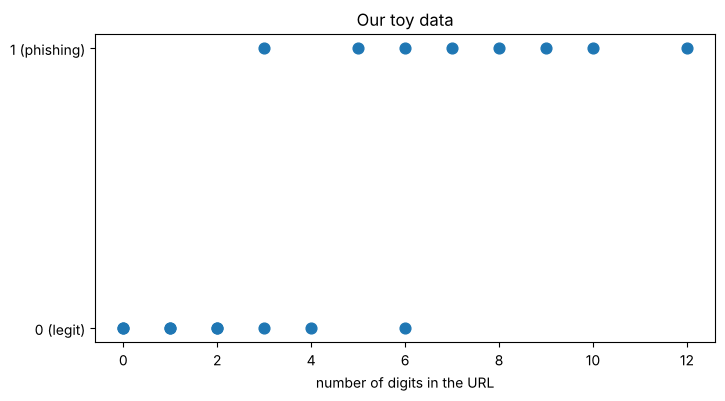

In [3]:
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=60, zorder=3)
plt.yticks([0, 1], ['0 (legit)', '1 (phishing)'])
plt.xlabel('number of digits in the URL')
plt.title('Our toy data')
plt.show()

Notice the **overlap** in the middle. A URL with 3 or 6 digits could go either way. Real data is like this too, so we don't want a hard yes/no. We want a **probability**: *"this URL is 80% likely to be phishing."*

---
## 2. Why not just draw a straight line?
You may have seen **linear regression**, which fits the best straight line through the points. Let's try it.

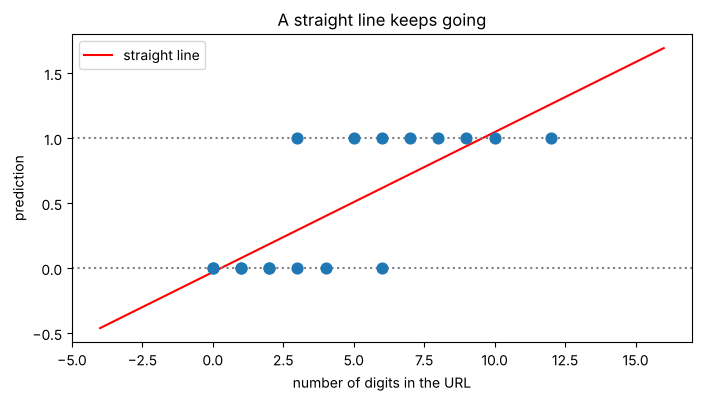

Prediction for 16 digits: [1.69]
Prediction for -3 digits: [-0.35]


In [4]:
X_toy = x.reshape(-1, 1)          # sklearn wants a 2D table of features, even with just one feature
lin = LinearRegression().fit(X_toy, y)

grid = np.linspace(-4, 16, 200).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=60, zorder=3)
plt.plot(grid, lin.predict(grid), color='red', label='straight line')
plt.axhline(0, color='gray', ls=':'); plt.axhline(1, color='gray', ls=':')
plt.xlabel('number of digits in the URL'); plt.ylabel('prediction')
plt.legend(); plt.title('A straight line keeps going')
plt.show()

print('Prediction for 16 digits:', lin.predict([[16]]).round(2))
print('Prediction for -3 digits:', lin.predict([[-3]]).round(2))

The line goes **above 1 and below 0**. A probability of 1.3 or −0.2 doesn't mean anything.

We need something that:
- stays between 0 and 1,
- goes up smoothly as `x` goes up,
- flattens out at the ends (going from 30 to 31 digits shouldn't matter much; it's already obviously phishing).

---
## 3. The sigmoid: squishing any number into 0–1
The **sigmoid** function takes any number `z` and squishes it into the range 0 to 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

You don't need to memorize the formula. Just look at what it does:

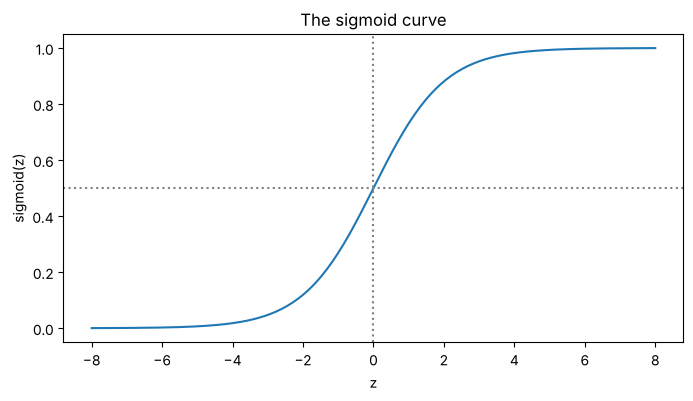

,z,sigmoid(z)
0,-6,0.002
1,-2,0.119
2,-1,0.269
3,0,0.500
4,1,0.731
5,2,0.881
6,6,0.998


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color='gray', ls=':'); plt.axvline(0, color='gray', ls=':')
plt.xlabel('z'); plt.ylabel('sigmoid(z)')
plt.title('The sigmoid curve')
plt.show()

pd.DataFrame({'z': [-6, -2, -1, 0, 1, 2, 6],
              'sigmoid(z)': sigmoid(np.array([-6, -2, -1, 0, 1, 2, 6])).round(3)})

- Big negative `z` → close to **0**
- `z = 0` → exactly **0.5**
- Big positive `z` → close to **1**

### Logistic regression = straight line + sigmoid
Logistic regression does two steps:
1. Compute a score with a straight line: $z = w \cdot x + b$
   - `w` is the **weight** (how much each digit matters)
   - `b` is the **bias** or **intercept** (where we start)
2. Squish the score: $p = \sigma(z)$.

Finally, to get a yes/no answer, compare `p` to a **threshold** (0.5 by default). If `p ≥ 0.5`, predict phishing.

### Try it yourself
Change `w` and `b` below and rerun the cell. Try to make the curve fit the dots well.
- What happens when `w` gets bigger? When it's negative?
- What does changing `b` do?

The **log loss** printed at the bottom measures how wrong the curve is. **Lower is better.** Start at about 0.6. Can you get it below 0.35?

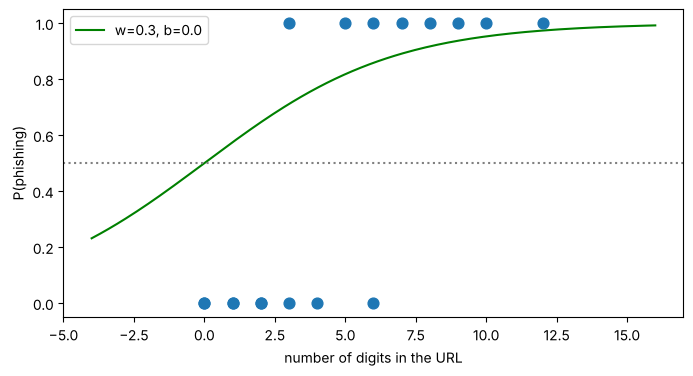

log loss: 0.639


In [6]:
w = 0.3     # try 0.5, 1, 2, -1
b = 0.0     # try -1, -3, -5

p = sigmoid(w * x + b)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=60, zorder=3)
plt.plot(grid, sigmoid(w * grid + b), color='green', label=f'w={w}, b={b}')
plt.axhline(0.5, color='gray', ls=':')
plt.xlabel('number of digits in the URL'); plt.ylabel('P(phishing)')
plt.legend(); plt.show()

print('log loss:', round(log_loss(y, p), 3))

---
## 4. How does the model pick `w` and `b`?
You just did it by hand. The computer does the same thing.

It needs a way to score how bad a curve is. That score is the **log loss**. For each point:
- If the URL **is** phishing (`y = 1`), the loss is $-\log(p)$
- If it **isn't** (`y = 0`), the loss is $-\log(1 - p)$

Here's what that looks like for a phishing URL:

In [7]:
p_vals = np.array([0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.01])
pd.DataFrame({'model says P(phishing)': p_vals,
              'loss if it really IS phishing': (-np.log(p_vals)).round(2)})

,model says P(phishing),loss if it really IS phishing
0,0.99,0.01
1,0.90,0.11
2,0.70,0.36
3,0.50,0.69
4,0.30,1.20
5,0.10,2.30
6,0.01,4.61


Being **confident and wrong** (saying 1% when it's really phishing) costs a lot more than being unsure. So the model learns to be confident only when the data supports it.

**Training** means trying different values of `w` and `b` and keeping the ones with the lowest average log loss. scikit-learn does this with an algorithm (a cousin of *gradient descent*) that nudges `w` and `b` downhill until the loss stops shrinking.

---
## 5. Let scikit-learn do it

In [8]:
model = LogisticRegression()
model.fit(X_toy, y)

w_fit = model.coef_[0][0]
b_fit = model.intercept_[0]
print(f'learned w = {w_fit:.3f}')
print(f'learned b = {b_fit:.3f}')
print('log loss  =', round(log_loss(y, model.predict_proba(X_toy)[:, 1]), 3))

learned w = 0.787
learned b = -3.653
log loss  = 0.302


How does that compare to your best guess in the try-it cell?

### The decision boundary
The model switches from "legit" to "phishing" where `p = 0.5`. That's where `z = 0`, so `w·x + b = 0`, which means **x = −b / w**.

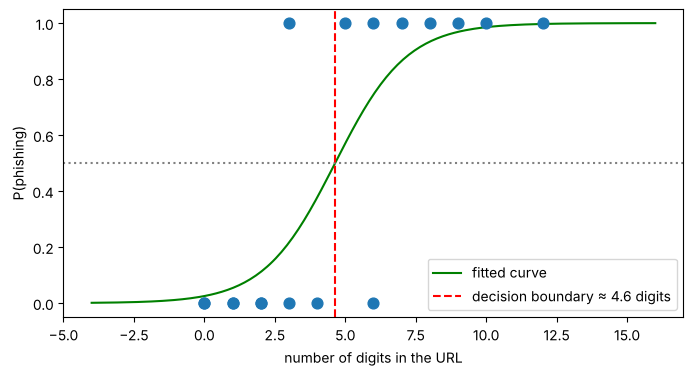

In [9]:
boundary = -b_fit / w_fit

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=60, zorder=3)
plt.plot(grid, model.predict_proba(grid)[:, 1], color='green', label='fitted curve')
plt.axhline(0.5, color='gray', ls=':')
plt.axvline(boundary, color='red', ls='--', label=f'decision boundary ≈ {boundary:.1f} digits')
plt.xlabel('number of digits in the URL'); plt.ylabel('P(phishing)')
plt.legend(); plt.show()

### `predict_proba` vs. `predict`
- `predict_proba` gives the probabilities. Column 0 is P(class 0), column 1 is P(class 1). We almost always want column 1: `[:, 1]`.
- `predict` gives the 0/1 answer using the 0.5 threshold.

In [10]:
new_urls = np.array([[0], [3], [5], [8], [15]])
pd.DataFrame({'digits': new_urls.ravel(),
              'P(phishing)': model.predict_proba(new_urls)[:, 1].round(3),
              'prediction': model.predict(new_urls)})

,digits,P(phishing),prediction
0,0,0.025,0
1,3,0.216,0
2,5,0.571,1
3,8,0.934,1
4,15,1.000,1


### Reading the weight
- **Positive** weight → more of this feature means **more likely** class 1
- **Negative** weight → more of this feature means **less likely** class 1
- **Near zero** → the feature doesn't change much

For a more exact reading: each extra unit of `x` **multiplies the odds** of phishing by $e^{w}$.

In [11]:
print(f'Each extra digit multiplies the odds of phishing by {np.exp(w_fit):.2f}')

Each extra digit multiplies the odds of phishing by 2.20


> **Odds vs. probability:** if P = 0.75, the odds are 0.75 / 0.25 = 3 ("3 to 1"). Odds are what the weight acts on directly, which is why the effect on *probability* is bigger in the middle of the S-curve and tiny at the ends.

---
## 6. Many features at once
Real models use many features. The idea doesn't change, there are just more terms:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b \qquad p = \sigma(z)$$

Each feature gets its own weight. Let's try a real dataset: the **Wisconsin breast cancer** dataset (built into scikit-learn). Each row is a tumor described by measurements from a scan. We'll predict whether it's **malignant (1)** or **benign (0)**.

In [12]:
data = load_breast_cancer(as_frame=True)

features = ['mean radius', 'mean texture', 'mean smoothness',
            'mean concave points', 'mean symmetry']
X = data.frame[features]
y = 1 - data.target   # scikit-learn codes malignant as 0; flip it so 1 = malignant, the thing we want to catch

print(X.shape)
print(y.value_counts())
X.head()

(569, 5)
target
0    357
1    212
Name: count, dtype: int64


,mean radius,mean texture,mean smoothness,mean concave points,mean symmetry
0,17.99,10.38,0.11840,0.14710,0.2419
1,20.57,17.77,0.08474,0.07017,0.1812
2,19.69,21.25,0.10960,0.12790,0.2069
3,11.42,20.38,0.14250,0.10520,0.2597
4,20.29,14.34,0.10030,0.10430,0.1809


> **Pick your positive class on purpose.** Precision and recall are measured for class **1**. Make class 1 the thing you're trying to *catch* (phishing, malignant, fraud). If you leave it backwards, your "recall" will measure how well you find the harmless cases.

### Split, then scale
- **Split** first: train on 80%, test on 20% that the model never sees. `stratify=y` keeps the class ratio the same in both.
- **Scale**: `mean radius` is around 14 while `mean smoothness` is around 0.1. `StandardScaler` puts every feature on the same scale (mean 0, standard deviation 1) so the weights can be compared. Fit it on the **training data only**.

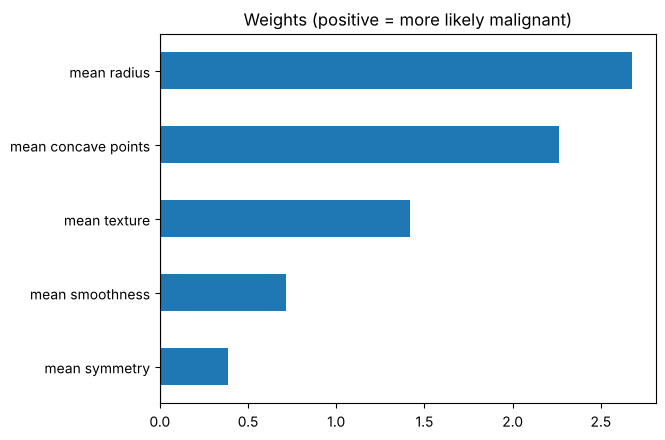

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_s, y_train)

weights = pd.Series(model.coef_[0], index=features).sort_values()
weights.plot(kind='barh')
plt.axvline(0, color='black', lw=0.8)
plt.title('Weights (positive = more likely malignant)')
plt.show()

Because we scaled, each weight means *"what happens when this feature goes up by one standard deviation."* Bigger bars mean the feature matters more **in this model**.

**Notw**: Weights show what the model uses, not what *causes* the outcome. And when two features carry the same information (like radius and area), they can split or even flip the weight between them.

---
## 7. Is the model any good?
### Start with a baseline
Always ask: what would a lazy model that **always guesses the most common class** score?

In [14]:
y_pred = model.predict(X_test_s)

print('Model accuracy:   ', round(accuracy_score(y_test, y_pred), 3))
print('Baseline accuracy:', round(y_test.value_counts(normalize=True).max(), 3))

Model accuracy:    0.939
Baseline accuracy: 0.632


### The confusion matrix
Rows show the **truth**, columns show what the model **predicted**.

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actually 0** | True negative (TN): correct | False positive (FP): false alarm |
| **Actually 1** | False negative (FN): missed it | True positive (TP): correct |

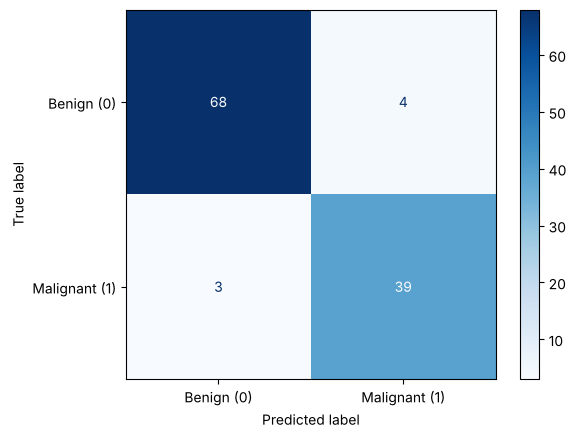

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Benign (0)', 'Malignant (1)'], cmap='Blues')
plt.show()

### The four main metrics
| Metric | Question it answers | Formula |
|---|---|---|
| **Accuracy** | What fraction did we get right overall? | (TP + TN) / everything |
| **Precision** | Of the cases we **flagged**, how many were really positive? | TP / (TP + FP) |
| **Recall** | Of all the **real** positives, how many did we catch? | TP / (TP + FN) |
| **F1** | One number balancing precision and recall | 2 · P · R / (P + R) |

Which one matters most depends on which mistake is worse. Missing a malignant tumor (FN) is worse than a false alarm that leads to a follow-up test (FP), so here we care a lot about **recall**.

In [16]:
print('Accuracy: ', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:   ', round(recall_score(y_test, y_pred), 3))
print('F1:       ', round(f1_score(y_test, y_pred), 3))

Accuracy:  0.939
Precision: 0.907
Recall:    0.929
F1:        0.918


### The classification report
`classification_report` prints these for **both** classes at once.

In [17]:
print(classification_report(y_test, y_pred, target_names=['benign (0)', 'malignant (1)']))

               precision    recall  f1-score   support

   benign (0)       0.96      0.94      0.95        72
malignant (1)       0.91      0.93      0.92        42

     accuracy                           0.94       114
    macro avg       0.93      0.94      0.93       114
 weighted avg       0.94      0.94      0.94       114



How to read it:
- Each **row** treats that class as the positive one. The `malignant` row is what we computed above.
- **support** = how many test cases are really in that class.
- **macro avg** = plain average of the two rows (treats classes equally).
- **weighted avg** = average weighted by support (bigger class counts more).

---
## 8. The threshold is a choice
`predict` uses 0.5, but you can pick any cutoff. 

Lower it to **catch more** positives (higher recall) at the cost of **more false alarms** (lower precision).

In [18]:
probs = model.predict_proba(X_test_s)[:, 1]

rows = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_t = (probs >= t).astype(int)
    rows.append({'threshold': t,
                 'precision': precision_score(y_test, preds_t, zero_division=0),
                 'recall':    recall_score(y_test, preds_t)})
pd.DataFrame(rows).round(3)

,threshold,precision,recall
0,0.1,0.778,1.000
1,0.2,0.800,0.952
2,0.3,0.833,0.952
3,0.4,0.851,0.952
4,0.5,0.907,0.929
5,0.6,0.925,0.881
6,0.7,0.944,0.810
7,0.8,0.971,0.810
8,0.9,0.967,0.690


---
## 9. Common mistakes
| Mistake | Why it's a problem | Fix |
|---|---|---|
| Positive class is backwards | Precision/recall measure the wrong thing | Make 1 = the thing you want to catch |
| Only reporting accuracy | Looks great on imbalanced data even if the model is useless | Compare to the baseline; check precision and recall |
| Fitting the scaler on all the data | Test info leaks into training | `fit_transform` on train, `transform` on test |
| Comparing weights of unscaled features | Weights depend on units | Scale first |
| Reading weights as causes | The model finds patterns, not causes | Say "associated with" |
| Passing `y` as a column (`shape (n, 1)`) | sklearn warns `DataConversionWarning` | Use a 1D array: `y.ravel()` or a pandas Series |
| `ConvergenceWarning` | The optimizer ran out of steps | Scale features, or raise `max_iter` |

---
## 10. Cheat sheet
```python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression().fit(X_train_s, y_train)

model.coef_, model.intercept_          # weights w and bias b
model.predict_proba(X_test_s)[:, 1]    # P(class 1)
model.predict(X_test_s)                # 0/1 using threshold 0.5
```